# DVF 2020-2025 Load


In [1]:
from pathlib import Path
import sys

root = Path.cwd()
sys.path.insert(0, str(root.parent / "src"))

from utils_dfs_load import load_and_filter_dvf


In [2]:
dvf_df = load_and_filter_dvf()

Total rows: 5.9 mln
After drop_na and price > 0:  5.8 mln
 (0.98 of total)


In [13]:
dvf_df.head()

,date_mutation,code_departement,valeur_fonciere,surface_reelle_bati,latitude,longitude,price_sqm,log_price,log_price_sqm
17,2020-07-02,01,77000.0,115.0,46.30802,5.198842,669.565217,11.251561,6.506629
31,2020-07-01,01,279000.0,122.0,46.264536,5.215936,2286.885246,12.538967,7.734946
32,2020-07-02,01,177650.0,80.0,46.396034,5.061938,2220.625000,12.087571,7.705544
36,2020-07-03,01,169111.0,86.0,46.212201,5.251962,1966.406977,12.038311,7.583963
37,2020-07-02,01,190000.0,114.0,46.20075,5.428764,1666.666667,12.154779,7.418581


In [3]:
dvf_df.head()

,date_mutation,code_departement,valeur_fonciere,surface_reelle_bati,latitude,longitude,price_sqm,log_price,log_price_sqm
17,2020-07-02,01,77000.0,115.0,46.30802,5.198842,669.565217,11.251561,6.506629
31,2020-07-01,01,279000.0,122.0,46.264536,5.215936,2286.885246,12.538967,7.734946
32,2020-07-02,01,177650.0,80.0,46.396034,5.061938,2220.625000,12.087571,7.705544
36,2020-07-03,01,169111.0,86.0,46.212201,5.251962,1966.406977,12.038311,7.583963
37,2020-07-02,01,190000.0,114.0,46.20075,5.428764,1666.666667,12.154779,7.418581


In [4]:
# Value counts by year from date_mutation
(dvf_df["date_mutation"].dt.year.value_counts()/1e6).sort_index()


date_mutation
2020    0.682809
2021    1.399613
2022    1.337332
2023    1.050008
2024    0.958762
2025    0.392114
Name: count, dtype: float64

In [5]:
dvf_df.head(5)

,date_mutation,code_departement,valeur_fonciere,surface_reelle_bati,latitude,longitude,price_sqm,log_price,log_price_sqm
17,2020-07-02,01,77000.0,115.0,46.30802,5.198842,669.565217,11.251561,6.506629
31,2020-07-01,01,279000.0,122.0,46.264536,5.215936,2286.885246,12.538967,7.734946
32,2020-07-02,01,177650.0,80.0,46.396034,5.061938,2220.625000,12.087571,7.705544
36,2020-07-03,01,169111.0,86.0,46.212201,5.251962,1966.406977,12.038311,7.583963
37,2020-07-02,01,190000.0,114.0,46.20075,5.428764,1666.666667,12.154779,7.418581


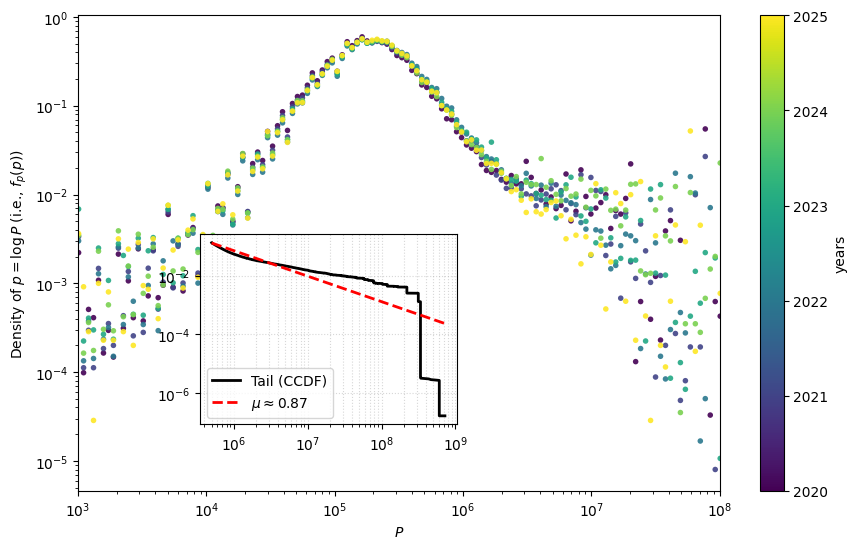

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

def empirical_ccdf(x: np.ndarray):
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    x = x[x > 0]
    x_sorted = np.sort(x)
    n = len(x_sorted)
    ranks = np.arange(1, n + 1)
    ccdf = (n - ranks) / n
    # evita zero in scala log
    ccdf = np.maximum(ccdf, 1.0 / n)
    return x_sorted, ccdf

def fit_mu_mle_for_ccdf(prices: np.ndarray, xmin: float):
    """Se CCDF ~ (x/xmin)^(-mu), allora mu MLE = n / sum(log(x/xmin))."""
    x = np.asarray(prices, float)
    x = x[np.isfinite(x)]
    x = x[x >= xmin]
    if len(x) < 20:
        return np.nan
    return len(x) / np.sum(np.log(x / xmin))

def plot_paper_like_pdf_logprice(
    df: pd.DataFrame,
    date_col="date_mutation",
    price_col="valeur_fonciere",
    log_price_col="log_price",
    years=None,
    bins_p=220,               # numero bin in p=log(P)
    p_range=None,             # (pmin, pmax) oppure None
    xmin_tail=500_000,
    cmap_name="viridis",
):
    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
    df = df[df[date_col].notna()]
    df["year"] = df[date_col].dt.year

    if log_price_col not in df.columns:
        df[log_price_col] = np.log(df[price_col])

    if years is None:
        years = sorted(df["year"].unique())
    else:
        years = sorted(years)

    # colormap per anni
    norm = Normalize(vmin=min(years), vmax=max(years))
    cmap = plt.get_cmap(cmap_name)
    sm = ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])

    fig, ax = plt.subplots(figsize=(9, 5.6))

    # definisci bin in p una volta sola per confrontabilità tra anni
    all_p = df[log_price_col].to_numpy(float)
    all_p = all_p[np.isfinite(all_p)]
    if p_range is None:
        pmin, pmax = np.quantile(all_p, [0.001, 0.999])
    else:
        pmin, pmax = p_range

    p_edges = np.linspace(pmin, pmax, bins_p + 1)
    p_centers = 0.5 * (p_edges[:-1] + p_edges[1:])
    P_centers = np.exp(p_centers)

    # per ogni anno: istogramma in p (densità)
    for y in years:
        d = df[df["year"] == y]
        p = d[log_price_col].to_numpy(float)
        p = p[np.isfinite(p)]
        if len(p) < 100:
            continue

        hist, _ = np.histogram(p, bins=p_edges, density=True)  # densità in p
        # Per un look "scatter" come il paper:
        ax.scatter(P_centers, hist, s=16, alpha=0.9, color=cmap(norm(y)), edgecolors="none")

    ax.set_xscale("log")
    ax.set_xlim(1e3, 1e8)
    ax.set_yscale("log")
    ax.set_xlabel(r"$P$")
    ax.set_ylabel(r"Density of $p=\log P$ (i.e., $f_p(p)$)")  # etichetta corretta

    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label("years")

    # -------- inset: tail su CCDF dei prezzi (standard) + fit mu ----------
    prices = df[price_col].to_numpy(float)
    prices = prices[np.isfinite(prices)]
    prices = prices[prices > 0]

    xs, ccdf = empirical_ccdf(prices)
    mask = xs >= xmin_tail
    xs_t, ccdf_t = xs[mask], ccdf[mask]

    mu_hat = fit_mu_mle_for_ccdf(prices, xmin=xmin_tail)

    inset = ax.inset_axes([0.19, 0.14, 0.40, 0.40])
    inset.plot(xs_t, ccdf_t, lw=2, color="black", label="Tail (CCDF)")
    if np.isfinite(mu_hat) and len(xs_t) > 0:
        ccdf_xmin = np.mean(prices > xmin_tail)
        ccdf_fit = ccdf_xmin * (xs_t / xmin_tail) ** (-mu_hat)
        inset.plot(xs_t, ccdf_fit, lw=2, ls="--", color="red", label=rf"$\mu \approx {mu_hat:.2f}$")

    inset.set_xscale("log")
    inset.set_yscale("log")
    inset.grid(True, which="both", ls=":", alpha=0.5)
    inset.legend(frameon=True)

    fig.tight_layout()
    return fig, ax

# USO:
fig, ax = plot_paper_like_pdf_logprice(dvf_df, xmin_tail=500_000)
# plt.show()


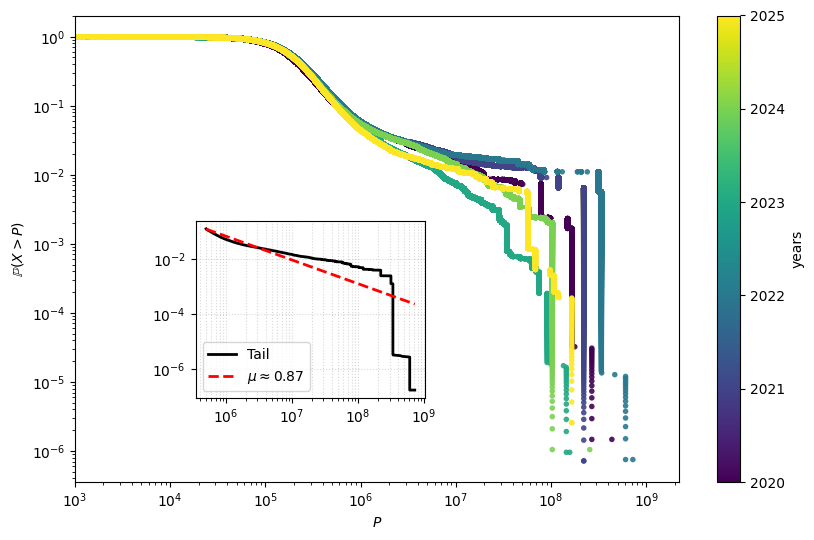

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# -----------------------------
# Helpers
# -----------------------------
def empirical_ccdf(x: np.ndarray):
    """
    Empirical CCDF evaluated at the sample points.
    Returns (x_sorted, ccdf), where ccdf[i] = P(X > x_sorted[i]).
    """
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    x = x[x > 0]  # price-like positive support; remove if using log_price directly

    x_sorted = np.sort(x)
    n = len(x_sorted)
    # CCDF at each sorted point: fraction strictly greater
    # Using (n - rank)/n with rank starting at 1
    ranks = np.arange(1, n + 1)
    ccdf = (n - ranks) / n
    # avoid zeros for log scale (keep last few points off if needed)
    # Here we add a tiny epsilon to allow log plotting; alternatively drop zeros.
    eps = 1.0 / n
    ccdf = np.maximum(ccdf, eps)
    return x_sorted, ccdf

def fit_powerlaw_ccdf(x_tail: np.ndarray, xmin: float):
    """
    MLE fit for Pareto tail assuming P(X >= xmin) and X ~ Pareto(mu)
    where CCDF ~ (x/xmin)^(-mu).
    Returns mu_hat.
    """
    x_tail = np.asarray(x_tail, dtype=float)
    x_tail = x_tail[np.isfinite(x_tail)]
    x_tail = x_tail[x_tail >= xmin]
    if len(x_tail) < 10:
        return np.nan
    mu_hat = len(x_tail) / np.sum(np.log(x_tail / xmin))
    return mu_hat

# -----------------------------
# Main plotting function
# -----------------------------
def plot_ccdf_by_year(
    df: pd.DataFrame,
    years=None,
    x_mode="paper_like",          # "paper_like" or "price"
    price_col="valeur_fonciere",
    log_price_col="log_price",
    date_col="date_mutation",
    xmin_tail=500_000,            # tail threshold (like paper)
    cmap_name="viridis"
):
    """
    x_mode:
      - "paper_like": CCDF of log_price but x-axis uses price (exp(log_price)) i.e. valeur_fonciere.
                     This mimics the 'caption says log-price' + axis labeled P behavior.
      - "price": CCDF of price (standard monotone CCDF).
    """
    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
    df = df[df[date_col].notna()]
    df["year"] = df[date_col].dt.year

    if years is None:
        years = sorted(df["year"].dropna().unique())
    else:
        years = sorted(years)

    # Colormap mapping years -> colors
    norm = Normalize(vmin=min(years), vmax=max(years))
    cmap = plt.get_cmap(cmap_name)
    sm = ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])

    fig, ax = plt.subplots(figsize=(8.5, 5.5))

    # Plot each year
    for y in years:
        d = df[df["year"] == y]
        if x_mode == "paper_like":
            # CCDF of log_price, but evaluate at sorted log_price and show x as price
            p = d[log_price_col].to_numpy(dtype=float)
            p = p[np.isfinite(p)]
            if len(p) < 50:
                continue
            p_sorted = np.sort(p)
            n = len(p_sorted)
            ranks = np.arange(1, n + 1)
            ccdf = (n - ranks) / n
            eps = 1.0 / n
            ccdf = np.maximum(ccdf, eps)

            x = np.exp(p_sorted)  # show as price P
        elif x_mode == "price":
            x = d[price_col].to_numpy(dtype=float)
            if len(x) < 50:
                continue
            x, ccdf = empirical_ccdf(x)
        else:
            raise ValueError("x_mode must be 'paper_like' or 'price'")

        ax.scatter(x, ccdf, s=16, alpha=0.9, color=cmap(norm(y)), edgecolors="none")

    # Axis style: log-log like the paper
    ax.set_xscale("log")
    ax.set_xlim(1e3, None)
    ax.set_yscale("log")
    ax.set_xlabel(r"$P$")
    ax.set_ylabel(r"$\mathbb{P}(X > P)$")

    # Colorbar
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label("years")

    # -----------------------------
    # Inset: tail fit on pooled data (all years) or pick a specific year
    # -----------------------------
    # We'll pool all years for stability (change if you want per-year tail)
    all_prices = df[price_col].to_numpy(dtype=float)
    all_prices = all_prices[np.isfinite(all_prices)]
    all_prices = all_prices[all_prices > 0]

    # Tail points
    tail = all_prices[all_prices >= xmin_tail]
    mu_hat = fit_powerlaw_ccdf(all_prices, xmin=xmin_tail)

    # CCDF for tail plot (standard CCDF of price)
    x_tail_sorted, ccdf_tail = empirical_ccdf(all_prices)
    mask = x_tail_sorted >= xmin_tail
    x_tail_sorted = x_tail_sorted[mask]
    ccdf_tail = ccdf_tail[mask]

    # Theoretical CCDF fit: ccdf(x) = ccdf(xmin) * (x/xmin)^(-mu)
    # Use empirical ccdf at xmin as scale anchor:
    if len(x_tail_sorted) > 0 and np.isfinite(mu_hat):
        # approximate ccdf(xmin) from data:
        ccdf_xmin = np.mean(all_prices > xmin_tail)
        ccdf_fit = ccdf_xmin * (x_tail_sorted / xmin_tail) ** (-mu_hat)
    else:
        ccdf_fit = None

    inset = ax.inset_axes([0.20, 0.18, 0.38, 0.38])  # [x0, y0, w, h] in axes fraction
    inset.plot(x_tail_sorted, ccdf_tail, lw=2, color="black", label="Tail")
    if ccdf_fit is not None:
        inset.plot(x_tail_sorted, ccdf_fit, lw=2, ls="--", color="red", label=rf"$\mu \approx {mu_hat:.2f}$")

    inset.set_xscale("log")
    inset.set_yscale("log")
    inset.grid(True, which="both", ls=":", alpha=0.5)
    inset.legend(frameon=True)

    # Tight layout
    fig.tight_layout()
    return fig, ax


# -----------------------------
# Usage
# -----------------------------
# df = pd.read_parquet(...) or pd.read_csv(...)
# Ensure log_price exists; if not:
# df["log_price"] = np.log(df["valeur_fonciere"])

# Plot like the paper (caption says log-price, x labeled as P)
fig, ax = plot_ccdf_by_year(dvf_df, x_mode="paper_like", xmin_tail=500_000)

# Or plot the standard monotone CCDF of price:
#fig, ax = plot_ccdf_by_year(dvf_df, x_mode="price", xmin_tail=500_000)

# plt.show()


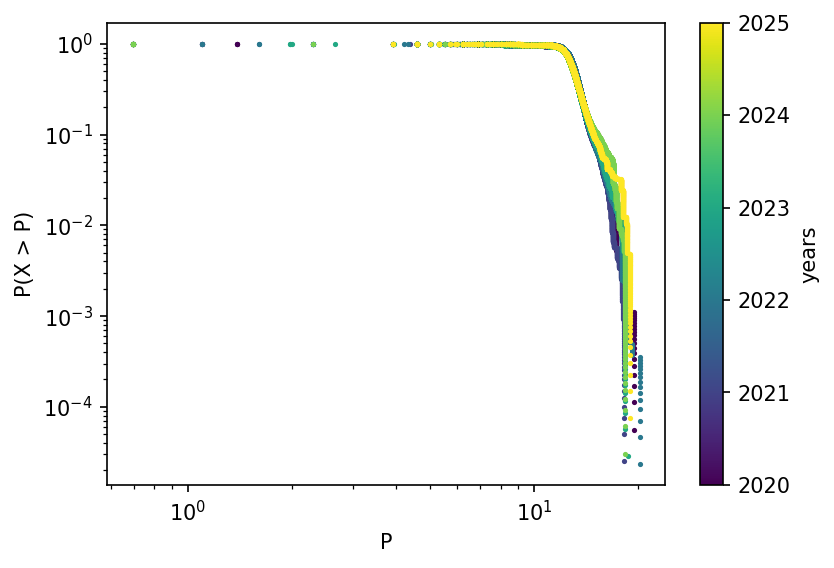

In [25]:
import numpy as np
import matplotlib.pyplot as plt

mask_dep = dvf_df["code_departement"] == "75"

# CCDF of valeur_fonciere by year
df_plot = dvf_df[mask_dep].dropna(subset=["date_mutation", "log_price"]).copy()
df_plot["year"] = df_plot["date_mutation"].dt.year

years = sorted(df_plot["year"].dropna().unique())
cmap = plt.cm.viridis

fig, ax = plt.subplots(figsize=(6.0, 4.0), dpi=150)

for i, year in enumerate(years):
    values = df_plot.loc[df_plot["year"] == year, "log_price"].values
    if values.size == 0:
        continue
    values = np.sort(values)
    ccdf = 1.0 - (np.arange(1, values.size + 1) / values.size)
    ax.loglog(values, ccdf, marker='.', linestyle='None', ms=3, color=cmap(i / max(len(years) - 1, 1)))

norm = plt.Normalize(min(years), max(years))
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("years")

ax.set_xlabel("P")
#ax.set_xlim(1e3, 1e8)
ax.set_ylabel("P(X > P)")
ax.grid(False)
plt.show()


In [22]:
mask_dep = dvf_df["code_departement"] == "75"

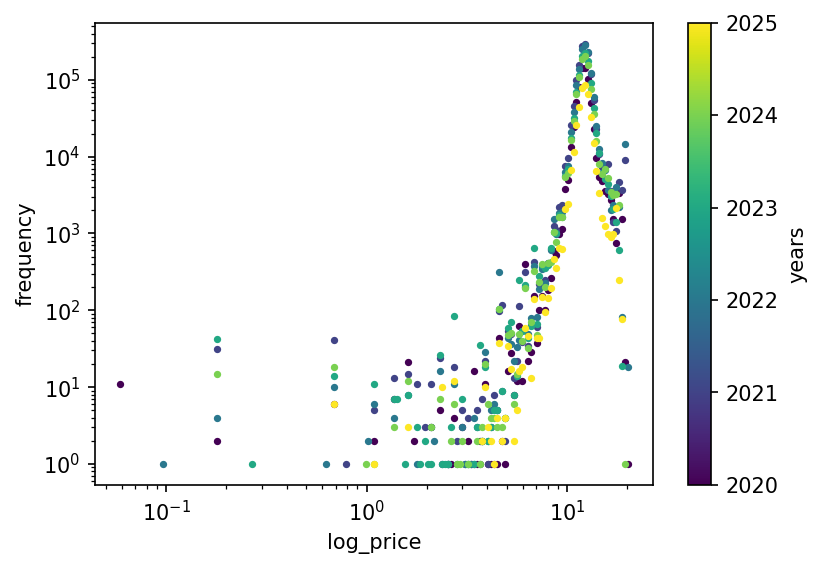

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Absolute frequency (histogram counts) of valeur_fonciere by year
df_plot = dvf_df.dropna(subset=["date_mutation", "log_price"]).copy()
df_plot["year"] = df_plot["date_mutation"].dt.year

years = sorted(df_plot["year"].dropna().unique())
cmap = plt.cm.viridis

values_all = df_plot["log_price"].values
values_all = values_all[values_all > 0]
bins = np.logspace(np.log10(values_all.min()), np.log10(values_all.max()), 180)
bin_centers = (bins[:-1] * bins[1:]) ** 0.5

fig, ax = plt.subplots(figsize=(6.0, 4.0), dpi=150)

for i, year in enumerate(years):
    values = df_plot.loc[df_plot["year"] == year, "log_price"].values
    values = values[values > 0]
    if values.size == 0:
        continue
    counts, _ = np.histogram(values, bins=bins)
    ax.loglog(bin_centers, counts, marker='.', linestyle='None', ms=5, color=cmap(i / max(len(years) - 1, 1)))

norm = plt.Normalize(min(years), max(years))
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("years")

ax.set_xlabel("log_price")

ax.set_ylabel("frequency")
#ax.set_xlim(1e3, 1e8)
ax.grid(False)
plt.show()
